# Trident Chemwidgets를 이용한 인터랙티브 모델 평가

이번 튜토리얼에서는 [*그래프 합성곱 소개* 튜토리얼](https://github.com/deepchem/deepchem/blob/master/examples/tutorials/Introduction_to_Graph_Convolutions.ipynb)을 토대로, [Trident Chemwidgets](https://github.com/tridentbio/trident-chemwidgets)(TCW) 패키지를 사용해 여러분이 학습시킨 모델과 상호작용하고 테스트하는 방법을 보여드립니다.

새로운 데이터(코너 케이스 포함)로 모델을 평가하는 것은 모델 배포(deployment)를 향한 중요한 단계입니다. 하지만 테스트할 새 분자를 인터랙티브하게 생성하는 일은 좀처럼 간단하지 않습니다. TCW는 더 큰 데이터셋의 일부를 추출하고, 모델에 테스트할 새 분자를 그릴 수 있는 여러 도구를 제공합니다. Trident Chemwidgets 라이브러리의 전체 문서는 [여기](https://www.trident.bio/trident-chemwidgets/html/index.html)에서 확인할 수 있습니다.

## Kaggle에서 실행하기

이 노트북은 Kaggle에서 실행할 수 있습니다. 아래 배지를 클릭하면 Kaggle에서 바로 열립니다.

[![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https://github.com/isg-yhlee93/lecture/blob/main/Molecular%20Machine%20Learning/6_Interactive_Model_Evaluation_with_Trident_Chemwidgets.ipynb)


# 사전 준비 패키지 설치


In [ ]:
!pip install -qq --pre deepchem
!pip install -qq trident-chemwidgets seaborn

# 불필요한 경고·로그 메시지 끄기 (화면을 깔끔하게 보기 위함)
import warnings
warnings.filterwarnings('ignore')   # 파이썬 경고 숨기기
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')      # RDKit 로그 끄기


이 튜토리얼에는 Trident Chemwidgets 0.2.0 이상 버전이 필요합니다. 다음 명령으로 설치된 버전을 확인할 수 있습니다:


In [2]:
import trident_chemwidgets as tcw
print(tcw.__version__)


0.2.1


이 튜토리얼 전반에서, Trident Chemwidgets 패키지의 클래스를 호출할 때 `tcw`라는 약칭을 사용하겠습니다.


# 데이터 살펴보기

먼저 Tox21 데이터셋을 불러오고, 미리 정의된 학습(train)·검증(validation)·테스트(test) 분할을 추출하는 것부터 시작하겠습니다.


In [ ]:
import deepchem as dc

tasks, datasets, transformers = dc.molnet.load_tox21(featurizer='GraphConv')
train_dataset, valid_dataset, test_dataset = datasets


그런 다음 RDKit을 사용해 각 학습 예제에 대한 추가 특징을 계산할 수 있습니다. 구체적으로, 각 분자의 [logP](https://en.wikipedia.org/wiki/Partition_coefficient)와 [분자량(molecular weight)](https://en.wikipedia.org/wiki/Molecular_mass)을 계산하여 이 새로운 데이터를 데이터프레임으로 반환하겠습니다.


In [5]:
import rdkit.Chem as Chem
from rdkit.Chem.Crippen import MolLogP
from rdkit.Chem.Descriptors import MolWt
import pandas as pd
import torch

data = []

# 각 분자에 대해 logP와 분자량을 계산합니다.
for dataset, split in zip(datasets, ['train', 'valid', 'test']):
    for smiles in dataset.ids:
        mol = Chem.MolFromSmiles(smiles)
        logp = MolLogP(mol)
        mwt = MolWt(mol)
        data.append({
            'smiles': smiles,
            'logp': logp,
            'mwt': mwt,
            'split': split
        })
        
mol_data = pd.DataFrame(data)

mol_data.head()


[10:14:08] WARNING: not removing hydrogen atom without neighbors


,smiles,logp,mwt,split
0,CC(O)(P(=O)(O)O)P(=O)(O)O,-0.9922,206.027,train
1,CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C,4.8172,290.444,train
2,OC[C@H](O)[C@@H](O)[C@H](O)CO,-2.9463,152.146,train
3,CCCCCCCC(=O)[O-].CCCCCCCC(=O)[O-].[Zn+2],2.1911,351.802,train
4,CC(C)COC(=O)C(C)C,1.8416,144.214,train


## 1차원 분포(distribution)

히스토그램(histogram)을 사용해 1차원 분포를 살펴볼 수 있습니다. Matplotlib나 Seaborn 같은 정적(static) 플로팅 라이브러리의 히스토그램과 달리, TCW의 Histogram은 인터랙티브 기능을 제공합니다. TCW를 사용하면 데이터의 일부를 추출하고, 그래프 옆 갤러리에 화학 구조를 그리며, 추출한 데이터프레임 일부에 대한 참조를 저장할 수 있습니다. 아쉽게도 이런 상호작용성은 이식성(portability)을 희생하기 때문에, 이 튜토리얼에는 인터랙티브 시각화를 생성하는 코드와 함께 스크린샷도 포함했습니다. 직접(로컬이나 Colab에서) 이 튜토리얼을 실행하면 전체 데모 그래프를 표시하고 상호작용할 수 있습니다.

아래 그래프에서, 왼쪽에 결합된 데이터셋의 분자량 분포 히스토그램을 볼 수 있습니다. 실시간 위젯에서 그래프 영역 안을 클릭&드래그하면 분포의 일부를 추출해 더 자세히 살펴볼 수 있습니다. 선택된 부분의 배경은 회색으로 바뀌고, 선택된 데이터 포인트는 막대 안에서 청록색(teal)으로 표시됩니다. Histogram 위젯의 x축은 숫자형 또는 날짜형 데이터 타입과 모두 호환되므로, 어떤 속성이나 실험 데이터 수집 날짜를 기준으로 ML 데이터셋을 나눌 때 편리합니다.

<img src="./assets/trident_chemwidgets_data/Histogram.png" alt="Histogram 예시" width="1000"/>

위젯의 인터랙티브 예시를 생성하려면 다음 셀을 실행하세요:


In [6]:
hist = tcw.Histogram(data=mol_data, smiles='smiles', x='mwt')
hist


Histogram(data={'points': [{'smiles': 'CC(O)(P(=O)(O)O)P(=O)(O)O', 'x': 206.027, 'index': 0}, {'smiles': 'CC(C…

클릭&드래그로 데이터의 일부를 선택하면, 그래프 아래의 `SHOW STRUCTURES` 버튼을 눌러 선택된 구조들을 오른쪽 갤러리에서 볼 수 있습니다. `SAVE SELECTION`을 누른 뒤 다음 셀처럼 `hist.selection` 속성에 접근하면, 원본 데이터프레임에서 이 부분 집합을 추출할 수 있습니다. 이 작업 흐름은 단일 차원을 기준으로 데이터를 분할하는 등의 응용에 편리합니다.


In [7]:
hist.selection


,smiles,logp,mwt,split


## 2차원 또는 3차원 분포

히스토그램 외에도, TCW는 산점도(scatter plot)를 위한 클래스도 제공합니다. Scatter 클래스는 데이터의 두세 개 차원을 비교할 때 유용합니다. v0.2.0 기준으로, TCW Scatter는 x축과 y축뿐 아니라 각 점의 색상(`hue` 키워드)을 사용해 연속형 또는 이산형 변수를 표현할 수 있습니다. Histogram 예시와 마찬가지로, 그래프 영역 안을 클릭&드래그하여 x축과 y축을 따라 일부를 추출할 수 있습니다. Scatter 위젯은 x, y, hue 축에서 날짜도 지원합니다.

아래 이미지에서는, 분자량 값이 크지만 학습 예제가 거의 없는(주황색으로 표시된 점) 데이터셋의 일부를 선택하여, Scatter 위젯이 이상치(outlier) 식별에 어떻게 유용한지 보여줍니다. 경계 상자(bounding box)로 선택하는 것 외에도, 개별 점 위에 마우스를 올리면 해당 구조의 그림을 표시할 수 있습니다.

<img src="./assets/trident_chemwidgets_data/Scatter.png" alt="Scatter 예시" width="1000"/>

위젯의 인터랙티브 예시를 생성하려면 다음 셀을 실행하세요:


In [8]:
scatter = tcw.Scatter(data=mol_data, smiles='smiles', x='mwt', y='logp', hue='split')
scatter


Scatter(data={'points': [{'smiles': 'CC(O)(P(=O)(O)O)P(=O)(O)O', 'x': 206.027, 'y': -0.9922000000000002, 'hue'…

클릭&드래그로 데이터의 일부를 선택하면, 그래프 아래의 `SHOW STRUCTURES` 버튼을 눌러 선택된 구조들을 오른쪽 갤러리에서 볼 수 있습니다. `SAVE SELECTION`을 누른 뒤 다음 셀처럼 `scatter.selection` 속성에 접근하면, 원본 데이터프레임에서 이 부분 집합을 추출할 수 있습니다.


In [9]:
scatter.selection


,smiles,logp,mwt,split


# GraphConvModel 학습하기

학습 데이터를 살펴봤으니, 이제 12개의 Tox21 클래스를 예측하는 GraphConvModel을 학습시킬 수 있습니다. [*그래프 합성곱 소개* 튜토리얼](https://github.com/deepchem/deepchem/blob/master/examples/tutorials/Introduction_to_Graph_Convolutions.ipynb)의 학습 절차를 그대로 재현하겠습니다. 원본 튜토리얼과 동일하게 50 에폭(epoch) 동안 학습합니다.


In [1]:
# 다음 줄은 메모리 사용량과 관련된 pytorch 경고를 걸러냅니다.
# 이 경고들을 보고 싶다면 다음 줄을 주석 처리하세요.
import warnings; warnings.filterwarnings('ignore')

# 결과 재현성을 위해 pytorch 시드를 고정합니다.
import torch
torch.manual_seed(27)
n_tasks = len(tasks)
num_features = train_dataset.X[0].get_atom_features().shape[1]
model = dc.models.torch_models.GraphConvModel(n_tasks, mode='classification',number_input_features=[num_features,64])
model.fit(train_dataset, nb_epoch=50)


0.2595431746140894


이제 학습된 모델이 생겼으니, 학습 데이터셋과 테스트 데이터셋에 대한 AUROC 값을 확인할 수 있습니다:


In [11]:
metric = dc.metrics.Metric(dc.metrics.roc_auc_score)
print(f'학습 세트 점수: {model.evaluate(train_dataset, [metric], transformers)["roc_auc_score"]:.2f}')
print(f'테스트 세트 점수: {model.evaluate(test_dataset, [metric], transformers)["roc_auc_score"]:.2f}')


Training set score: 0.96
Test set score: 0.69


원본 튜토리얼과 마찬가지로, 모델이 미리 정의된 학습/테스트 분할에서 꽤 잘 동작하는 것을 볼 수 있습니다. 이제 실제 신약 개발 시나리오에서처럼, 이 모델을 사용해 학습 분포 밖에 있는 화합물들을 평가해 보겠습니다.


# 새로운 데이터로 모델 평가하기

ML 모델을 실제 운영(production)에 배포하기 위한 어려운 첫 단계 중 하나는, 새로운 데이터로 모델을 평가하는 것입니다. 여기서 새로운 데이터란, 초기 학습/검증/테스트 분포 밖의 데이터뿐 아니라, 아직 모델에 사용할 수 있도록 처리되지 않은 데이터까지 포함합니다.

TCW가 제공하는 JSME 위젯을 사용하면 관심 있는 분자들로 모델을 빠르게 테스트할 수 있습니다. 잘 알려진 치료제 분자인 이부프로펜(ibuprofen)으로 시작하겠습니다. 이부프로펜은 지금까지 모델을 평가한 어떤 데이터셋에도 포함되어 있지 않음을 확인할 수 있습니다:


In [12]:
print(f"Tox21 데이터셋에 이부프로펜 구조 포함 여부: {'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O' in mol_data['smiles']}")


Ibuprofen structure in Tox21 dataset: False


신약 개발 상황을 가정해 봅시다. 여러분이 이부프로펜에서 파생된 새로운 잠재적 치료제를 찾는 임무를 맡은 화학자라고 해보죠. 이상적으로는 테스트할 분자들이 독성이 낮아야 합니다. 여러분은 방금 Tox21 데이터로 독성 결과를 예측하는 위 모델을 개발했고, 이제 이를 사용해 파생 분자들을 1차 스크리닝(screening)하려 합니다. 이런 작업의 표준 흐름은 보통 ChemDraw 같은 프로그램으로 분자를 그리고, SMILES 형식으로 내보내고, 노트북으로 가져온 뒤, 데이터를 준비하여 모델에 통과시키는 과정을 포함합니다.

TCW를 사용하면 [JSME](https://jsme-editor.github.io/help.html) 위젯으로 노트북 안에서 직접 분자를 그리고 SMILES로 변환함으로써, 이 흐름의 처음 몇 단계를 건너뛸 수 있습니다. 심지어 `base_smiles` 인자로 기본 분자 구조를 지정할 수도 있어, 파생 분자를 생성하기에 아주 좋습니다. 여기서는 base_smiles 값을 이부프로펜의 SMILES 문자열인 `'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O'`로 설정하겠습니다. 아래는 JSME로 독성 모델에 테스트할 파생 분자 몇 개를 생성하는 스크린샷입니다.

<img src="./assets/trident_chemwidgets_data/JSME.png" alt="JSME 예시" width="1000"/>

직접 파생 분자 집합을 생성하려면 아래 셀을 실행하세요. 저장 집합에 SMILES 문자열을 추가하려면 인터페이스 아래의 `ADD TO SMILES LIST` 버튼을 누르세요. 원래의 기본 분자(여기서는 이부프로펜)를 다시 생성하려면 `RESET TO BASE SMILES` 버튼을 누르면 됩니다. 이 버튼을 사용하면 공통 출발 구조로부터 서로 다른 파생 분자들을 쉽게 만들 수 있습니다. 독성 모델에 테스트할 이부프로펜 파생 분자를 몇 개 만들어 보세요:


In [13]:
jsme = tcw.JSME(base_smiles='CC(C)CC1=CC=C(C=C1)C(C)C(=O)O')
jsme


JSME(base_smiles='CC(C)CC1=CC=C(C=C1)C(C)C(=O)O')

`jsme.smiles` 속성으로 SMILES에 접근할 수 있습니다. 이 호출은 위젯의 SMILES 목록에 추가된 SMILES 문자열들(JSME 인터페이스 오른쪽 분자 갤러리에 표시된 것들)의 리스트를 반환합니다.


In [14]:
print(jsme.smiles)


[]


이 노트북의 나머지 부분이 올바르게 실행되도록, 다음 셀은 (여러분이 위젯으로 직접 집합을 정의하지 않은 경우) 위 스크린샷의 SMILES들을 새 테스트 집합으로 설정합니다. 직접 그린 분자가 있다면 그것을 사용합니다.


In [15]:
# 직접 만들지 않은 경우를 대비해 미리 준비된 SMILES 목록을 제공하는 셀입니다.
if len(jsme.smiles) > 1:
    drawn_smiles = jsme.smiles
else:
    drawn_smiles = [
        'CC(C)Cc1ccc(C(C)C(=O)O)cc1',
        'CC(C)C(S)c1ccc(C(C)C(=O)O)cc1',
        'CCSC(c1ccc(C(C)C(=O)O)cc1)C(C)CC',
        'CCSC(c1ccc(C(C)C(=O)O)cc1)C(C)C(=O)O',
        'CC(C(=O)O)c1ccc(C(S)C(C)C(=O)O)cc1'
    ]


다음으로, 이 새 분자들을 테스트하기 위해 모델과 호환되는 데이터셋을 만들어야 합니다.


In [16]:
featurizer = dc.feat.ConvMolFeaturizer()
loader = dc.data.InMemoryLoader(tasks=list(train_dataset.tasks), featurizer=featurizer)
dataset = loader.create_dataset(drawn_smiles, shard_size=1)


마지막으로, 여기서 양성(positive) 결과에 대한 예측을 생성하고 그래프로 그릴 수 있습니다.


<Axes: >

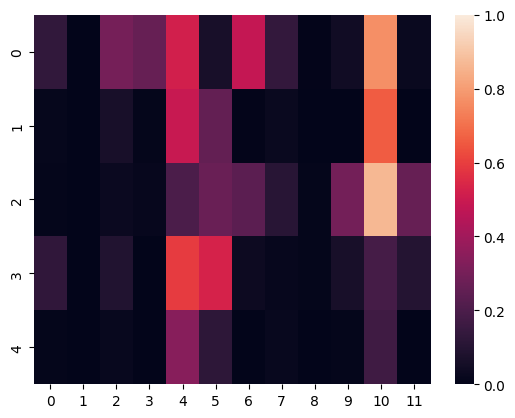

In [17]:
predictions = model.predict(dataset, transformers)[:, :, 1]

import seaborn as sns
sns.heatmap(predictions, vmin=0, vmax=1)


이제 추가 검토를 위해 가장 독성이 높을 것으로 예측된 화합물/분석(assay) 결과를 얻을 수 있습니다. 아래에서는 예측된 양성 적중(가장 독성이 높은) 중 최고값을 추출하여 분석 이름, SMILES 문자열, 그리고 구조 이미지를 표시합니다.


Most toxic result (predicted): SR-MMP, CCSC(c1ccc(C(C)C(=O)O)cc1)C(C)CC


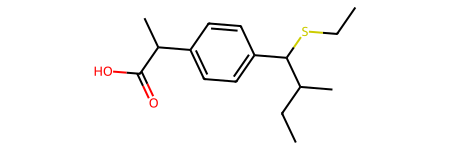

In [18]:
import numpy as np

# 예측값이 가장 큰 (분자, 분석) 위치를 찾습니다.
mol_idx, assay_idx = np.unravel_index(predictions.argmax(), predictions.shape)
smiles = drawn_smiles[mol_idx]

print(f'가장 독성이 높을 것으로 예측된 결과: {train_dataset.tasks[assay_idx]}, {smiles}')
mol = Chem.MolFromSmiles(smiles)
mol


# 모델의 예측 해석하기

종종 예측값만으로는 비용이 많이 드는 실험을 진행할지 결정하기에 충분하지 않습니다. 모델의 출력을 해석할 수 있게 해주는 지표(metric)도 함께 필요할 수 있습니다.

[그래프 합성곱 QSAR 모델 기반 분자의 원자 기여도 계산](https://github.com/deepchem/deepchem/blob/master/examples/tutorials/Atomic_Contributions_for_Molecules.ipynb) 튜토리얼을 토대로, 분자 내 각 원자가 예측 출력값에 기여하는 상대적 기여도를 계산할 수 있습니다. 이 기여(attribution) 전략을 통해, 화학자가 중요하다고 판단하는 분자 특징과 예측에 가장 큰 영향을 주는 특징이 서로 일치하는지 확인할 수 있습니다. 화학자의 해석과 모델의 해석 지표가 일치한다면, 이는 모델이 해당 과제에 잘 맞는다는 신호일 수 있습니다. 다만 그 역(逆)이 반드시 성립하는 것은 아닙니다. 모델은 숙련된 화학자조차 완전히 이해하지 못하는 정확한 예측을 해낼 능력이 있을 수도 있습니다. 이것은 머신러닝 실무자의 도구 상자에 있는 하나의 도구일 뿐입니다.

먼저 `ConvMolFeaturizer`의 내장 `per_atom_fragmentation` 인자를 사용하겠습니다. 이는 각각 원자 하나씩 제거된 ConvMol 객체들의 목록을 생성합니다.


In [19]:
featurizer = dc.feat.ConvMolFeaturizer(per_atom_fragmentation=True)
mol_list = featurizer(smiles)
loader = dc.data.InMemoryLoader(tasks=list(train_dataset.tasks),
                                featurizer=dc.feat.DummyFeaturizer())
dataset = loader.create_dataset(mol_list[0], shard_size=1)


그런 다음 이 예측들을 모델에 통과시켜, 앞 절에서 지정한 분자와 분석(assay)에 대한 예측값을 가져올 수 있습니다.


In [20]:
full_molecule_prediction = predictions[mol_idx, assay_idx]
fragment_predictions = model.predict(dataset, transformers)[:, assay_idx, 0]
# 기여도 = 분자 전체 예측 - 조각 예측 (원자를 제거했을 때의 독성 변화)
contributions = pd.DataFrame({
    'Change in predicted toxicity': 
    (full_molecule_prediction - fragment_predictions).round(3)
})


TCW의 InteractiveMolecule 위젯을 사용하면 기여도 점수를 분자 위에 겹쳐 표시할 수 있어, 각 원자가 최종 예측에 미치는 상대적 중요도를 쉽게 평가할 수 있습니다. 원자 하나를 클릭하면 구조 오른쪽에 표시되는 카드에서 기여도 데이터를 확인할 수 있습니다. 이 패널에서는 그래프의 원자에 색을 입힐 기준 변수도 선택할 수 있습니다.

<img src="./assets/trident_chemwidgets_data/InteractiveMolecule.png" alt="InteractiveMolecule 예시" width="1000"/>

아래 셀을 실행하면 인터랙티브 위젯을 생성할 수 있습니다.


In [21]:
tcw.InteractiveMolecule(smiles, data = contributions)


InteractiveMolecule(data=[{'Change in predicted toxicity': 0.847000002861023}, {'Change in predicted toxicity'…

# 마무리하며

이번 튜토리얼에서는 DeepChem 기반 ML 작업 흐름에 Trident Chemwidgets를 통합하는 방법을 배웠습니다. TCW는 분자 ML 작업 흐름을 염두에 두고 만들어졌지만, 일반적인 케모인포매틱스(cheminformatics) 노트북에도 잘 어울립니다.
